In [1]:
import os
os.chdir("..") # Ek folder piche jane ke liye
print(os.getcwd()) # Check karein ke ab path 'psl_ai_platform' par hai ya nahi

c:\Users\User\Desktop\psl_ai_platform


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("reports/eda/injury/rolling_workload/bowler_rolling_workload_features.csv")
df.head()

,match_id,match_date,bowler,balls_bowled,runs_conceded,wickets_taken,overs_bowled,balls_last_7_days,balls_last_14_days,matches_last_7_days,matches_last_14_days,days_since_last_match,back_to_back_match,short_recovery_flag,overs_last_7_days,overs_last_14_days,fatigue_signal_score,high_recent_workload_flag,high_match_density_flag,high_fatigue_flag
0,1211672,2020-11-14,A Lyth,6,4,0,1.00,0,0,0,0,NaN,0,0,0.0,0.0,0.0,False,False,False
1,1211675,2020-11-15,A Lyth,13,22,0,2.17,6,6,1,1,1.0,1,1,1.0,1.0,8.5,False,False,False
2,1527553,2026-03-27,A Zampa,24,26,0,4.00,0,0,0,0,NaN,0,0,0.0,0.0,0.0,False,False,False
3,1527557,2026-03-29,A Zampa,24,12,0,4.00,24,24,1,1,2.0,0,1,4.0,4.0,11.5,False,False,True
4,1527561,2026-04-02,A Zampa,25,28,0,4.17,48,48,2,2,4.0,0,0,8.0,8.0,19.0,True,False,True


In [4]:
df.columns.tolist()

['match_id',
 'match_date',
 'bowler',
 'balls_bowled',
 'runs_conceded',
 'wickets_taken',
 'overs_bowled',
 'balls_last_7_days',
 'balls_last_14_days',
 'matches_last_7_days',
 'matches_last_14_days',
 'days_since_last_match',
 'back_to_back_match',
 'short_recovery_flag',
 'overs_last_7_days',
 'overs_last_14_days',
 'fatigue_signal_score',
 'high_recent_workload_flag',
 'high_match_density_flag',
 'high_fatigue_flag']

In [5]:
df[["bowler", "match_date", "balls_bowled", "balls_last_7_days", "matches_last_14_days", "fatigue_signal_score"]].head(20)

,bowler,match_date,balls_bowled,balls_last_7_days,matches_last_14_days,fatigue_signal_score
0,A Lyth,2020-11-14,6,0,0,0.00
1,A Lyth,2020-11-15,13,6,1,8.50
2,A Zampa,2026-03-27,24,0,0,0.00
3,A Zampa,2026-03-29,24,24,1,11.50
4,A Zampa,2026-04-02,25,48,2,19.00
5,A Zampa,2026-04-09,24,25,3,12.84
6,A Zampa,2026-04-11,24,24,3,14.50
7,AD Russell,2016-02-04,12,0,0,0.00
8,AD Russell,2016-02-05,29,12,1,10.50
9,AD Russell,2016-02-07,24,41,2,18.66


In [6]:
bowler_name = "Shaheen Shah Afridi"
bowler_df = df[df["bowler"] == bowler_name].copy()
bowler_df

,match_id,match_date,bowler,balls_bowled,runs_conceded,wickets_taken,overs_bowled,balls_last_7_days,balls_last_14_days,matches_last_7_days,matches_last_14_days,days_since_last_match,back_to_back_match,short_recovery_flag,overs_last_7_days,overs_last_14_days,fatigue_signal_score,high_recent_workload_flag,high_match_density_flag,high_fatigue_flag
3032,1128820,2018-02-23,Shaheen Shah Afridi,20,35,0,3.33,0,0,0,0,NaN,0,0,0.00,0.00,0.00,False,False,False
3033,1128822,2018-02-24,Shaheen Shah Afridi,14,12,0,2.33,20,20,1,1,1.0,1,1,3.33,3.33,13.16,False,False,True
3034,1128825,2018-02-26,Shaheen Shah Afridi,19,39,0,3.17,34,34,2,2,2.0,0,1,5.67,5.67,16.34,False,False,True
3035,1128837,2018-03-09,Shaheen Shah Afridi,22,6,0,3.67,0,53,0,3,11.0,0,0,0.00,8.83,4.50,False,True,False
3036,1128841,2018-03-11,Shaheen Shah Afridi,25,45,0,4.17,22,41,1,2,2.0,0,1,3.67,6.83,12.34,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3115,1527552,2026-03-26,Shaheen Shah Afridi,24,33,0,4.00,0,0,0,0,305.0,0,0,0.00,0.00,0.00,False,False,False
3116,1527557,2026-03-29,Shaheen Shah Afridi,26,18,0,4.33,24,24,1,1,3.0,0,0,4.00,4.00,9.50,False,False,False
3117,1527562,2026-04-03,Shaheen Shah Afridi,19,32,0,3.17,26,50,1,2,5.0,0,0,4.33,8.33,11.66,False,False,True
3118,1527567,2026-04-09,Shaheen Shah Afridi,18,26,0,3.00,19,69,1,3,6.0,0,0,3.17,11.50,10.84,False,True,True


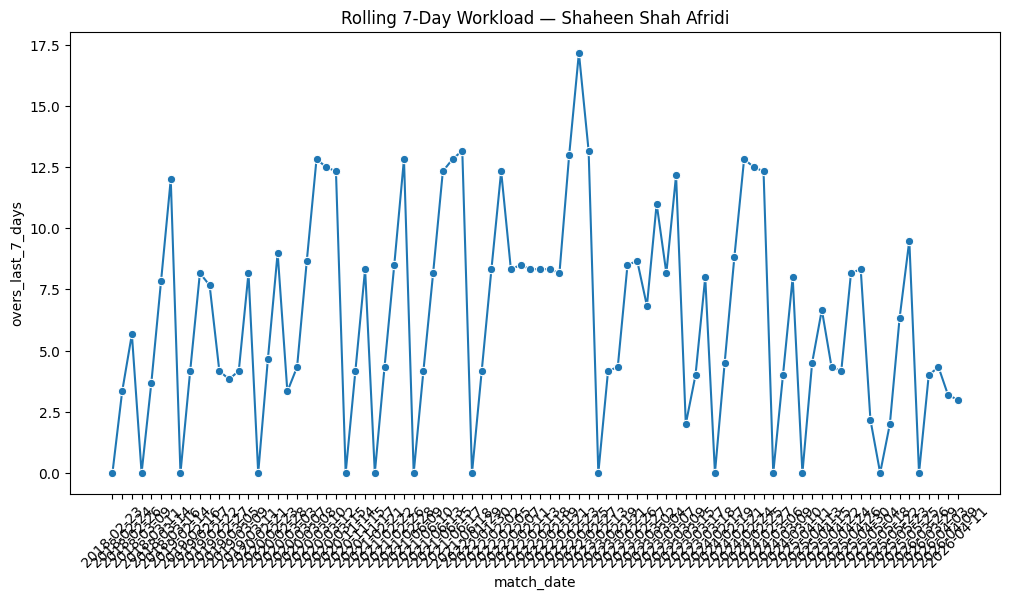

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=bowler_df, x="match_date", y="overs_last_7_days", marker="o")
plt.xticks(rotation=45)
plt.title(f"Rolling 7-Day Workload — {bowler_name}")
plt.show()  

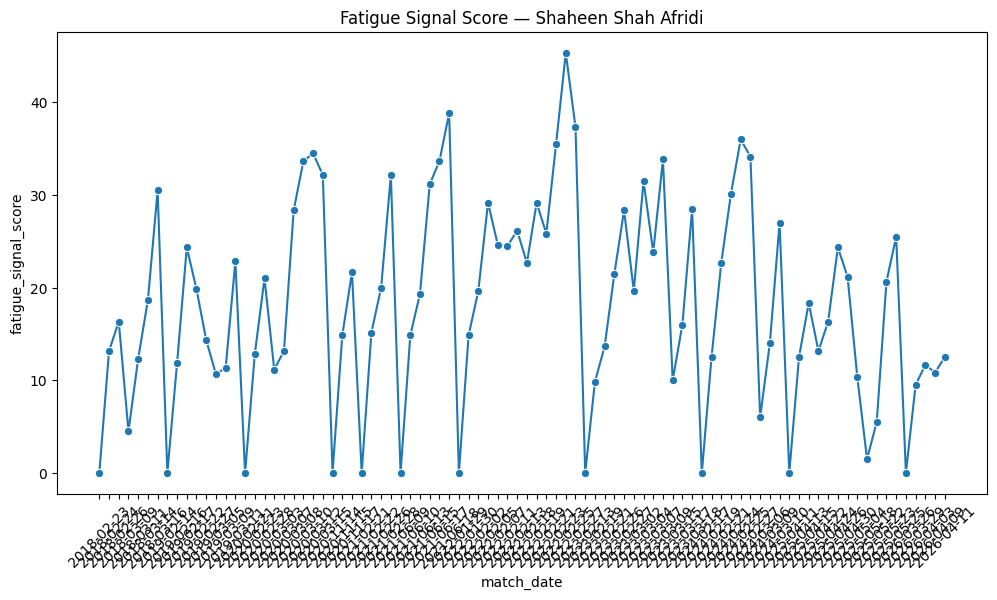

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=bowler_df, x="match_date", y="fatigue_signal_score", marker="o")
plt.xticks(rotation=45)
plt.title(f"Fatigue Signal Score — {bowler_name}")
plt.show()